In [1]:
#import nltk
#nltk.download('all')


# 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# 2.LOAD DATASET

In [21]:
import pandas as pd

df = pd.read_csv(r"C:\Users\lenovo\Desktop\ds_projects\dtaset\emotion_dataset_100k.csv")
df.head()

,sentence,emotion
0,"Ugh, how can something that's been sitting out...",disgust
1,"Ugh, get it off me, get it away from me, what ...",disgust
2,The thought of eating that congealed leftover ...,disgust
3,A sour taste spreads through my mouth like a s...,disgust
4,It felt like someone had dumped a bucket of ro...,disgust


# 3.DATASET UNDERSTANDING 

In [23]:
print(df.shape)
df.info()
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

(99746, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99746 entries, 0 to 99745
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sentence  99746 non-null  object
 1   emotion   99746 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB

Missing Values:
sentence    0
emotion     0
dtype: int64

Duplicates: 0


# 4. CLEANING EMOTION LABELS

In [24]:
df['emotion'] = df['emotion'].astype(str).str.lower().str.strip()
df['emotion'] = df['emotion'].str.replace(r'[^a-zA-Z]', '', regex=True)

print(df['emotion'].value_counts().head())

emotion
drive         9996
happiness     9995
loneliness    9992
sadness       9989
love          9980
Name: count, dtype: int64


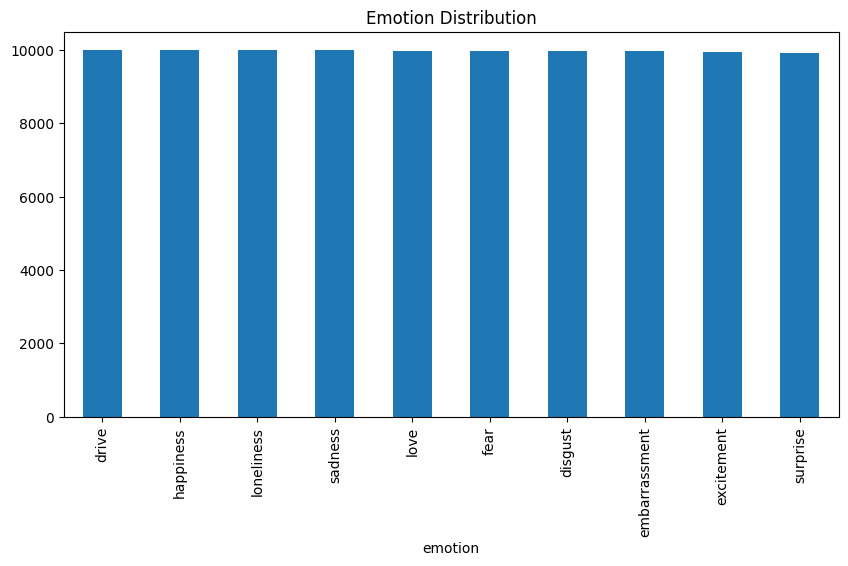

In [47]:
import matplotlib.pyplot as plt
df['emotion'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title('Emotion Distribution')
plt.show()

# 5.TEXT PREPROCESSING

In [27]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)

df['clean_text'] = df['sentence'].apply(clean_text)
df[['sentence','clean_text']].head()

,sentence,clean_text
0,"Ugh, how can something that's been sitting out...",ugh something thats sitting long still conside...
1,"Ugh, get it off me, get it away from me, what ...",ugh get get away even stuff
2,The thought of eating that congealed leftover ...,thought eating congealed leftover pizza break ...
3,A sour taste spreads through my mouth like a s...,sour taste spread mouth like stain thought cur...
4,It felt like someone had dumped a bucket of ro...,felt like someone dumped bucket rotting fish g...


# 6.TfIdf FEATURE ENGINEERING

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000)

X = tfidf.fit_transform(df['clean_text'])

y = df['emotion']

# 7.TRAIN TEST SPLIT

In [13]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 8. MODEL TRAINING

In [15]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# 9.EVALUATION

In [30]:
pred = model.predict(X_test)

print('Accuracy:', accuracy_score(y_test,pred))
print('\nClassification Report:')
print(classification_report(y_test,pred))

Accuracy: 0.8807518796992482

Classification Report:
               precision    recall  f1-score   support

      disgust       0.95      0.94      0.95      1992
        drive       0.88      0.89      0.88      2020
embarrassment       0.94      0.94      0.94      1977
   excitement       0.87      0.86      0.87      1967
         fear       0.90      0.90      0.90      2048
    happiness       0.88      0.88      0.88      2010
   loneliness       0.86      0.87      0.86      1951
         love       0.89      0.89      0.89      2014
      sadness       0.82      0.79      0.80      1964
     surprise       0.82      0.84      0.83      2007

     accuracy                           0.88     19950
    macro avg       0.88      0.88      0.88     19950
 weighted avg       0.88      0.88      0.88     19950



# SAMPLE DESTINATION DATASET

In [17]:
destinations = pd.DataFrame({

    "Emotion":[

        # Disgust
        "disgust","disgust","disgust","disgust",
        "disgust","disgust","disgust","disgust",

        # Drive
        "drive","drive","drive","drive",
        "drive","drive","drive","drive",

        # Embarrassment
        "embarrassment","embarrassment","embarrassment","embarrassment",
        "embarrassment","embarrassment","embarrassment","embarrassment",

        # Excitement
        "excitement","excitement","excitement","excitement",
        "excitement","excitement","excitement","excitement",

        # Fear
        "fear","fear","fear","fear",
        "fear","fear","fear","fear",

        # Happiness
        "happiness","happiness","happiness","happiness",
        "happiness","happiness","happiness","happiness",

        # Loneliness
        "loneliness","loneliness","loneliness","loneliness",
        "loneliness","loneliness","loneliness","loneliness",

        # Love
        "love","love","love","love",
        "love","love","love","love",

        # Sadness
        "sadness","sadness","sadness","sadness",
        "sadness","sadness","sadness","sadness",

        # Surprise
        "surprise","surprise","surprise","surprise",
        "surprise","surprise","surprise","surprise"
    ],

    "Destination":[

        # Disgust
        "Coorg","Wayanad","Munnar","Araku Valley",
        "Kodaikanal","Yercaud","Chikmagalur","Ooty",

        # Drive
        "Leh Ladakh","Spiti Valley","Manali","Auli",
        "Bir Billing","Rishikesh","Tawang","Kasol",

        # Embarrassment
        "Dharamshala","Kumarakom","Alleppey","Varkala",
        "Gokarna","Pondicherry","Mahabalipuram","Mysore",

        # Excitement
        "Mumbai","Delhi","Hyderabad","Bengaluru",
        "Goa","Jaipur","Chennai","Kolkata",

        # Fear
        "Chandigarh","Pune","Indore","Mysore",
        "Visakhapatnam","Nagpur","Surat","Bhubaneswar",

        # Happiness
        "Goa","Andaman Islands","Udaipur","Shimla",
        "Nainital","Mussoorie","Mount Abu","Srinagar",

        # Loneliness
        "Rishikesh","Dharamshala","Kumarakom","Alleppey",
        "Varkala","Gokarna","Wayanad","Munnar",

        # Love
        "Udaipur","Goa","Andaman Islands","Srinagar",
        "Shimla","Nainital","Mussoorie","Mount Abu",

        # Sadness
        "Coorg","Munnar","Ooty","Kodaikanal",
        "Araku Valley","Chikmagalur","Yercaud","Wayanad",

        # Surprise
        "Leh Ladakh","Tawang","Spiti Valley","Andaman Islands",
        "Rann of Kutch","Ziro Valley","Hampi","Majuli"
    ],

    "Reason":[

        # Disgust
        "Fresh air and natural beauty to reset your mind",
        "Dense forests and peaceful environment",
        "Tea gardens and refreshing climate",
        "Green valleys and scenic landscapes",
        "Calm lakes and misty hills",
        "Quiet hill station away from crowds",
        "Coffee estates and serenity",
        "Cool weather and scenic viewpoints",

        # Drive
        "Challenging roads and adventure",
        "Remote landscapes encouraging exploration",
        "Adventure sports and trekking",
        "Snow sports and outdoor activities",
        "World-famous paragliding destination",
        "Rafting and thrilling experiences",
        "Offbeat mountain exploration",
        "Popular backpacking destination",

        # Embarrassment
        "Peaceful environment for self-reflection",
        "Quiet lakeside retreat",
        "Relaxing backwater experience",
        "Less crowded beaches",
        "Calm coastal destination",
        "Peaceful French-inspired town",
        "Historic coastal getaway",
        "Safe and relaxing atmosphere",

        # Excitement
        "Nightlife and entertainment",
        "Bustling city attractions",
        "Modern culture and food scene",
        "Vibrant urban lifestyle",
        "Beach parties and water sports",
        "Historic attractions and markets",
        "City life with beaches",
        "Art, culture and festivals",

        # Fear
        "Safe and well-planned city",
        "Modern infrastructure and security",
        "Clean and organized environment",
        "Tourist-friendly destination",
        "Peaceful coastal city",
        "Comfortable urban experience",
        "Well-developed transportation",
        "Safe cultural destination",

        # Happiness
        "Fun-filled beach vacation",
        "Beautiful island experience",
        "Romantic lakes and palaces",
        "Pleasant hill station",
        "Beautiful lakes and views",
        "Scenic mountain retreat",
        "Relaxing hill destination",
        "Houseboats and breathtaking scenery",

        # Loneliness
        "Ideal for meditation and yoga",
        "Peaceful spiritual atmosphere",
        "Quiet lakeside relaxation",
        "Backwaters offering solitude",
        "Cliffside views and tranquility",
        "Serene beaches",
        "Nature and self-discovery",
        "Peaceful tea plantations",

        # Love
        "Romantic lake city",
        "Beach destination for couples",
        "Perfect honeymoon destination",
        "Houseboats and mountain views",
        "Romantic hill station",
        "Beautiful lakeside moments",
        "Pleasant weather and scenery",
        "Quiet romantic escape",

        # Sadness
        "Nature therapy and relaxation",
        "Peaceful tea gardens",
        "Refreshing climate and scenery",
        "Calming lakes and forests",
        "Green valley landscapes",
        "Coffee plantations and peace",
        "Quiet environment for healing",
        "Nature retreat and rejuvenation",

        # Surprise
        "Unique high-altitude landscapes",
        "Hidden gem in Northeast India",
        "Dramatic mountain scenery",
        "Unexpected island adventures",
        "White desert experience",
        "Beautiful untouched valley",
        "Ancient ruins and history",
        "World's largest river island"
    ]
})

# 10. RECOMMENDATION FUNCTION 

In [32]:
def recommend_trip(user_text):
    cleaned = clean_text(user_text)
    vector = tfidf.transform([cleaned])

    emotion = model.predict(vector)[0]

    probs = model.predict_proba(vector)
    confidence = probs.max()*100

    places = destinations[destinations['Emotion']==emotion]

    return emotion, confidence, places[['Destination','Reason']]

# USER INPUT

In [35]:

text = input("How are you feeling today? ")


emotion, confidence, emotion_places = recommend_trip(text)

print("\nDetected Emotion:", emotion)
print(f"Confidence Score: {confidence:.2f}%")

print("\nRecommended Destinations:\n")

for _, row in emotion_places.iterrows():
    print(f"📍 {row['Destination']}")
    print(f"   Reason: {row['Reason']}\n")

How are you feeling today?  i love to ride to beach



Detected Emotion: love
Confidence Score: 96.20%

Recommended Destinations:

📍 Udaipur
   Reason: Romantic lake city

📍 Goa
   Reason: Beach destination for couples

📍 Andaman Islands
   Reason: Perfect honeymoon destination

📍 Srinagar
   Reason: Houseboats and mountain views

📍 Shimla
   Reason: Romantic hill station

📍 Nainital
   Reason: Beautiful lakeside moments

📍 Mussoorie
   Reason: Pleasant weather and scenery

📍 Mount Abu
   Reason: Quiet romantic escape



In [44]:
import joblib

joblib.dump(model, "emotion_model.pkl")

joblib.dump(tfidf, "tfidf.pkl")

joblib.dump(destinations, "destinations.pkl")
print('Model Saved Successfully')

Model Saved Successfully
